# 06 — Dự báo: 2022 → 2023 (so với thực tế) → hiệu chỉnh → 2026 → 2027

Dữ liệu Expedia chỉ có **7 tháng của năm 2022**, nên một mình nó không thể cho biết giá vé thay đổi **qua các năm**.
Vì vậy dự báo được ghép từ **hai tầng**:

| Tầng | Dữ liệu | Cho biết |
|---|---|---|
| **Vi mô** | Expedia 2022 — 82 triệu vé (Spark) | mức giá riêng của từng tuyến, đường giá theo số ngày đặt trước |
| **Vĩ mô** | CPI vé máy bay 2005 → 08/2026 (BLS), lạm phát, nhiên liệu bay (EIA), giá vé thực tế theo tuyến 1993 → Q1/2024 (DOT) | xu hướng giá qua các năm, mùa vụ, tác động của lạm phát / nhiên liệu |

**Các bước**
1. Tương quan vĩ mô (theo tháng, 2005–2026): chỉ số nào đi cùng giá vé → chọn biến cho mô hình dự báo.
2. **Backtest 2023:** chỉ dùng thông tin đến hết 2022, dự báo giá vé từng tuyến cho 4 quý 2023 bằng 6 mô hình,
   rồi so với **giá thực tế 2023 của DOT**.
3. **Hiệu chỉnh cho sát 2023:** chọn mô hình tốt nhất + hệ số hiệu chỉnh độ lệch, kiểm tra lại trên **Q1/2024** (thực tế).
4. **Dự báo 2026 → 2027** theo tháng, theo tuyến, và theo **số ngày đặt trước** (đường giá đến ngày bay).

In [1]:
import sys, os, json, warnings
from IPython.display import display
sys.path.insert(0, os.path.abspath(".."))
from common import *
from viz import *
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pyspark.sql import functions as F
warnings.filterwarnings("ignore")

CLEAN = f"{EXTERNAL}/clean"
macro = pd.read_csv(f"{CLEAN}/macro_monthly.csv", parse_dates=["date"]).set_index("date").asfreq("MS")
dot = pd.read_csv(f"{CLEAN}/dot_route_quarter.csv")
print("Vĩ mô theo tháng:", macro.index.min().date(), "→", macro.index.max().date())
print("DOT theo tuyến × quý:", dot.year.min(), "→", f"{dot.year.max()}Q{dot[dot.year == dot.year.max()].quarter.max()}",
      "|", dot.pair.nunique(), "cặp sân bay")

Vĩ mô theo tháng: 2005-01-01 → 2026-08-01
DOT theo tuyến × quý: 1993 → 2024Q1 | 109 cặp sân bay


## 0. Tổng hợp dữ liệu Expedia 2022 bằng Spark (tầng vi mô)

In [2]:
spark = get_spark("06-forecast")
silver = spark.read.parquet(SILVER)
exp_rm = (silver.groupBy("route", "startingAirport", "destinationAirport", "flight_month")
          .agg(F.count("*").alias("n"), F.avg("totalFare").alias("avg_fare"),
               F.percentile_approx("totalFare", 0.5).alias("median_fare")).toPandas())
exp_curve = (silver.groupBy("route", "days_before")
             .agg(F.count("*").alias("n"), F.percentile_approx("totalFare", 0.5).alias("median_fare")).toPandas())
exp_curve_all = (silver.groupBy("days_before")
                 .agg(F.count("*").alias("n"), F.percentile_approx("totalFare", 0.5).alias("median_fare")).toPandas())
exp_rm["pair"] = ["-".join(sorted(p)) for p in zip(exp_rm.startingAirport, exp_rm.destinationAirport)]
exp_rm["date"] = pd.to_datetime(exp_rm.flight_month + "-01")
exp_rm["quarter"] = exp_rm.date.dt.quarter
print(exp_rm.route.nunique(), "tuyến (có chiều),", exp_rm.pair.nunique(), "cặp sân bay;",
      len(set(exp_rm.pair) & set(dot.pair)), "cặp có trong DOT")

234 tuyến (có chiều), 117 cặp sân bay; 109 cặp có trong DOT


## 1. Tương quan vĩ mô: chỉ số nào đi cùng giá vé? (theo tháng, 2005 → 08/2026)

Dùng **% thay đổi so với cùng kỳ năm trước** để loại bỏ xu hướng chung và mùa vụ, xét độ trễ 0–6 tháng.

In [3]:
m = macro.copy()
m["fuel_yoy"] = m["jet_fuel_usd_gal"].pct_change(12) * 100
rows = []
for col, name in [("inflation_yoy", "Lạm phát (CPI chung)"), ("fuel_yoy", "Giá nhiên liệu bay")]:
    for lag in range(0, 7):
        r = m["airfare_yoy"].corr(m[col].shift(lag))
        rows.append({"chỉ số": name, "cột": col, "độ trễ (tháng)": lag, "r với CPI vé máy bay (yoy)": round(r, 3)})
macro_corr = pd.DataFrame(rows)
macro_corr.to_csv(f"{EXPORTS}/06_macro_correlation.csv", index=False)
best_lag = macro_corr.loc[macro_corr.groupby("cột")["r với CPI vé máy bay (yoy)"].apply(lambda s: s.abs().idxmax())]
FUEL_LAG = int(best_lag.loc[best_lag["cột"] == "fuel_yoy", "độ trễ (tháng)"].iloc[0])
best_lag

,chỉ số,cột,độ trễ (tháng),r với CPI vé máy bay (yoy)
9,Giá nhiên liệu bay,fuel_yoy,2,0.739
0,Lạm phát (CPI chung),inflation_yoy,0,0.682


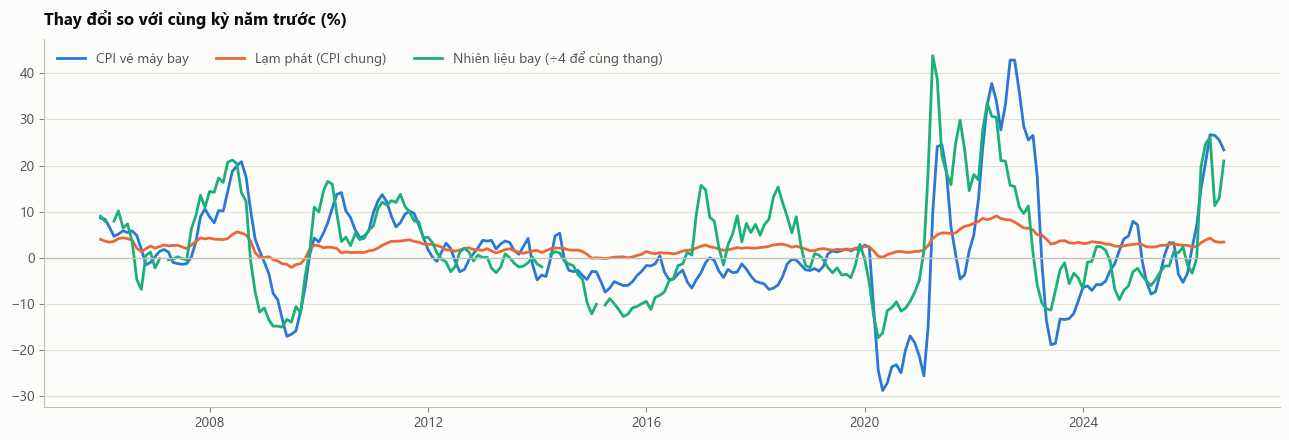

In [4]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(m.index, m.airfare_yoy, color=SERIES[0], label="CPI vé máy bay")
ax.plot(m.index, m.inflation_yoy, color=SERIES[1], label="Lạm phát (CPI chung)")
ax.plot(m.index, m.fuel_yoy / 4, color=SERIES[2], label="Nhiên liệu bay (÷4 để cùng thang)")
ax.axhline(0, color=AXIS, linewidth=1)
ax.set_title("Thay đổi so với cùng kỳ năm trước (%)"); ax.legend(ncol=3, loc="upper left")
plt.tight_layout(); plt.savefig(f"{EXPORTS}/fig_06_macro_yoy.png", dpi=150); plt.show()

## 2. Backtest 2023: chỉ dùng thông tin đến hết 2022

Dự báo **CPI vé máy bay theo tháng** cho 2023 bằng nhiều mô hình chuỗi thời gian, rồi đổi thành **hệ số tăng/giảm
của từng quý 2023 so với cùng quý 2022**. Giá dự báo của một tuyến = giá 2022 của tuyến đó × hệ số.

| Mô hình | Ý tưởng |
|---|---|
| Naive | Giá 2023 = giá cùng quý 2022 |
| Theo lạm phát | Giá tăng đúng bằng lạm phát chung dự báo (ARIMA trên CPI chung) |
| SARIMA | Mô hình mùa vụ trên CPI vé máy bay |
| Holt-Winters (ETS) | Làm trơn hàm mũ có xu hướng + mùa vụ |
| SARIMAX + nhiên liệu, lạm phát | SARIMA thêm biến ngoài được chọn ở bước 1 |
| SARIMA theo từng tuyến | Mô hình riêng cho chuỗi giá DOT 1993–2022 của mỗi tuyến |
| Expedia 2022 (dữ liệu trong máy) | Mức giá từng tuyến lấy từ 82 triệu vé Expedia, quy đổi sang thang DOT, × hệ số SARIMAX |

Đại dịch (04/2020 → 06/2021) được đánh dấu bằng biến giả `covid` để mô hình không học nhầm cú sập giá.

In [5]:
COVID = (m.index >= "2020-04-01") & (m.index <= "2021-06-01")
m["covid"] = COVID.astype(float)

def fc_monthly(train_end, steps, method):
    """Dự báo CPI vé máy bay theo tháng cho `steps` tháng sau `train_end`. Trả về (dự báo, cận dưới, cận trên)."""
    y = np.log(m.loc[:train_end, "cpi_airfare"])
    idx = pd.date_range(pd.Timestamp(train_end) + pd.offsets.MonthBegin(), periods=steps, freq="MS")
    covid_tr = m.loc[:train_end, ["covid"]]
    covid_fc = pd.DataFrame({"covid": 0.0}, index=idx)
    if method == "naive":
        f = y.shift(0).iloc[-12:].values
        f = np.resize(f, steps)
        return pd.Series(np.exp(f), idx), None, None
    if method == "sarima":
        r = SARIMAX(y, exog=covid_tr, order=(1, 1, 1), seasonal_order=(0, 1, 1, 12)).fit(disp=False)
        p = r.get_forecast(steps, exog=covid_fc)
    elif method == "ets":
        r = ExponentialSmoothing(y, trend="add", damped_trend=True, seasonal="add", seasonal_periods=12).fit()
        return pd.Series(np.exp(r.forecast(steps).values), idx), None, None
    elif method == "sarimax":
        ex = pd.DataFrame({"fuel": np.log(m["jet_fuel_usd_gal"]).shift(FUEL_LAG), "cpi_all": np.log(m["cpi_all"]),
                           "covid": m["covid"]}).bfill()
        ex_tr = ex.loc[:train_end]
        ex_fc = pd.DataFrame(index=idx)
        for col, order in [("fuel", (1, 1, 0)), ("cpi_all", (1, 1, 1))]:
            base = np.log(m.loc[:train_end, "jet_fuel_usd_gal" if col == "fuel" else "cpi_all"])
            fut = ARIMA(base, order=order, trend="t").fit().forecast(steps + FUEL_LAG if col == "fuel" else steps)
            if col == "fuel":   # với độ trễ L, L tháng đầu dùng giá nhiên liệu thực tế đã biết
                full = pd.concat([base, pd.Series(fut.values, pd.date_range(idx[0], periods=len(fut), freq="MS"))])
                ex_fc[col] = full.shift(FUEL_LAG).loc[idx].values
            else:
                ex_fc[col] = fut.values
        ex_fc["covid"] = 0.0
        r = SARIMAX(y, exog=ex_tr, order=(1, 1, 1), seasonal_order=(0, 1, 1, 12)).fit(disp=False)
        p = r.get_forecast(steps, exog=ex_fc)
    elif method == "inflation":
        # CPI vé máy bay cùng tháng năm trước × (CPI chung dự báo / CPI chung cùng tháng năm trước)
        base = np.log(m.loc[:train_end, "cpi_all"])
        cpi_all_fc = np.exp(ARIMA(base, order=(1, 1, 1), trend="t").fit().forecast(steps).values)
        air_last12 = m.loc[:train_end, "cpi_airfare"].iloc[-12:].values
        all_last12 = m.loc[:train_end, "cpi_all"].iloc[-12:].values
        out = [air_last12[i % 12] * cpi_all_fc[i] / all_last12[i % 12] for i in range(steps)]
        return pd.Series(out, idx), None, None
    ci = p.conf_int(alpha=0.2)   # khoảng tin cậy 80%
    return pd.Series(np.exp(p.predicted_mean.values), idx), np.exp(ci.iloc[:, 0].values), np.exp(ci.iloc[:, 1].values)

CPI_METHODS = {"naive": "Naive (= 2022)", "inflation": "Theo lạm phát", "sarima": "SARIMA",
               "ets": "Holt-Winters (ETS)", "sarimax": "SARIMAX + nhiên liệu, lạm phát"}
cpi_bt = pd.DataFrame({k: fc_monthly("2022-12-01", 12, k)[0] for k in CPI_METHODS})
cpi_bt["actual"] = m.loc["2023", "cpi_airfare"]
cpi_err = pd.DataFrame({CPI_METHODS[k]: {"MAPE_%": (abs(cpi_bt[k] / cpi_bt.actual - 1)).mean() * 100}
                        for k in CPI_METHODS}).T.round(2)
print("Sai số dự báo CPI vé máy bay 12 tháng của 2023:")
cpi_err

Sai số dự báo CPI vé máy bay 12 tháng của 2023:


,MAPE_%
Naive (= 2022),15.75
Theo lạm phát,16.29
SARIMA,12.19
Holt-Winters (ETS),7.05
"SARIMAX + nhiên liệu, lạm phát",7.72


In [6]:
def quarter_growth(cpi_fc, year, base_year):
    """Hệ số giá quý `year` so với cùng quý `base_year` (từ chuỗi CPI tháng: thực tế + dự báo)."""
    s = m["cpi_airfare"].copy()
    s = pd.concat([s[s.index < cpi_fc.index[0]], cpi_fc])
    q = s.groupby([s.index.year, s.index.quarter]).mean()
    return pd.Series({qq: q[(year, qq)] / q[(base_year, qq)] for qq in range(1, 5) if (year, qq) in q.index})

# --- Độ co giãn giữa giá vé thực tế (DOT) và CPI vé máy bay ---
# CPI dao động mạnh hơn giá vé thực bán trên các tuyến lớn. Ước lượng trên thay đổi so với cùng quý năm trước:
#   Δlog(giá DOT) = α + β · Δlog(CPI vé máy bay)
ELASTIC = " + co giãn DOT–CPI"

def fit_elasticity(end_year, end_q=4):
    piv = dot.pivot_table(index=["year", "quarter"], columns="pair", values="fare")
    piv = piv[[(y >= 2005) and ((y, q) <= (end_year, end_q)) for y, q in piv.index]]
    nat = piv.dropna(axis=1).mean(axis=1)             # chỉ số giá các tuyến có đủ dữ liệu
    cq = m.groupby([m.index.year, m.index.quarter])["cpi_airfare"].mean()
    df = pd.DataFrame({"fare": nat, "cpi": cq}).dropna()
    d = pd.DataFrame({"dl": np.log(df["fare"]).diff(4), "cl": np.log(df["cpi"]).diff(4)}).dropna()
    beta, alpha = np.polyfit(d.cl, d.dl, 1)
    return alpha, beta, d.cl.corr(d.dl)

def to_route_growth(g, alpha, beta, years=1):
    return np.exp(alpha * years + beta * np.log(g))

ALPHA22, BETA22, R22 = fit_elasticity(2022)
print(f"Co giãn (học trên 2005–2022): β = {BETA22:.3f}, α = {ALPHA22 * 100:+.2f}%/năm, r = {R22:.3f}")

# --- Mức giá 2022 theo cặp sân bay × quý (DOT) ---
d22 = dot[dot.year == 2022].set_index(["pair", "quarter"])["fare"]
actual23 = dot[dot.year == 2023].set_index(["pair", "quarter"])["fare"]
pairs = sorted(set(d22.index.get_level_values(0)) & set(actual23.index.get_level_values(0)))

bt = pd.DataFrame(index=pd.MultiIndex.from_product([pairs, [1, 2, 3, 4]], names=["pair", "quarter"]))
bt["actual"] = actual23
bt["fare_2022"] = d22
quarters = bt.index.get_level_values("quarter")
for k, name in CPI_METHODS.items():
    g = quarter_growth(cpi_bt[k], 2023, 2022) if k != "naive" else pd.Series(1.0, index=[1, 2, 3, 4])
    bt[name] = bt.fare_2022 * quarters.map(g).values
    if k in ("sarima", "ets", "sarimax"):           # cùng dự báo CPI, quy đổi sang giá vé tuyến qua hệ số co giãn
        bt[name + ELASTIC] = bt.fare_2022 * quarters.map(to_route_growth(g, ALPHA22, BETA22)).values

# --- SARIMA riêng cho từng tuyến trên chuỗi giá DOT theo quý ---
def route_series(pair, end_year, end_q=4):
    s = dot[dot.pair == pair].copy()
    s["p"] = pd.PeriodIndex.from_fields(year=s.year, quarter=s.quarter, freq="Q")
    s = s.set_index("p")["fare"].sort_index()
    s = s[s.index <= pd.Period(f"{end_year}Q{end_q}", "Q")]
    full = pd.period_range("2005Q1", s.index.max(), freq="Q")
    return np.log(s.reindex(full).interpolate().bfill())

def route_forecast(pair, end_year, steps, end_q=4):
    y = route_series(pair, end_year, end_q)
    cov = pd.Series(((y.index >= pd.Period("2020Q2", "Q")) & (y.index <= pd.Period("2021Q2", "Q"))).astype(float), index=y.index)
    try:
        r = SARIMAX(y, exog=cov, order=(1, 1, 0), seasonal_order=(0, 1, 1, 4)).fit(disp=False)
        return np.exp(r.forecast(steps, exog=np.zeros((steps, 1))).values)
    except Exception:
        return np.exp(np.resize(y.iloc[-4:].values, steps))

bt["SARIMA theo từng tuyến"] = np.concatenate([route_forecast(p, 2022, 4) for p in pairs])

# --- Expedia 2022 (dữ liệu trong máy): mức giá từng tuyến từ Expedia, quy đổi sang thang DOT ---
e_q = exp_rm.groupby(["pair", "quarter"]).apply(lambda g: np.average(g.avg_fare, weights=g.n), include_groups=False)
overlap = pd.concat([e_q.rename("exp"), d22.rename("dot")], axis=1).dropna()
K_SCALE = overlap["dot"].sum() / overlap["exp"].sum()     # 1 USD giá tìm kiếm Expedia ≈ K USD giá vé thực bán (DOT)
e_annual = exp_rm.groupby("pair").apply(lambda g: np.average(g.avg_fare, weights=g.n), include_groups=False)
dot_season = (d22 / d22.groupby("pair").transform("mean"))  # mùa vụ theo quý của từng tuyến (2022)
g_x = quarter_growth(cpi_bt["sarimax"], 2023, 2022)
bt["Expedia 2022 + SARIMAX"] = [
    e_annual.get(p, np.nan) * K_SCALE * dot_season.get((p, q), 1.0) * g_x[q] for p, q in bt.index]
print(f"Hệ số quy đổi Expedia → DOT: K = {K_SCALE:.3f} (trên {len(overlap)} cặp tuyến × quý trùng nhau năm 2022)")

Co giãn (học trên 2005–2022): β = 0.903, α = +0.45%/năm, r = 0.843


Hệ số quy đổi Expedia → DOT: K = 0.785 (trên 306 cặp tuyến × quý trùng nhau năm 2022)


In [7]:
MODELS = (list(CPI_METHODS.values()) + [CPI_METHODS[k] + ELASTIC for k in ("sarima", "ets", "sarimax")]
          + ["SARIMA theo từng tuyến", "Expedia 2022 + SARIMAX"])
bt = bt.dropna(subset=["actual"])
bt["Kết hợp (trung bình 2 mô hình tốt nhất)"] = np.nan
def score(df, cols):
    out = {}
    for c in cols:
        ok = df[[c, "actual"]].dropna()
        out[c] = {"MAPE_%": (abs(ok[c] / ok.actual - 1)).mean() * 100, "MAE_USD": abs(ok[c] - ok.actual).mean(),
                  "Bias_%": (ok[c].sum() / ok.actual.sum() - 1) * 100, "n": len(ok)}
    return pd.DataFrame(out).T.round(2)

s0 = score(bt, MODELS).sort_values("MAPE_%")
top2 = list(s0.index[:2])
bt["Kết hợp (trung bình 2 mô hình tốt nhất)"] = bt[top2].mean(axis=1)
MODELS.append("Kết hợp (trung bình 2 mô hình tốt nhất)")
bt_score = score(bt, MODELS).sort_values("MAPE_%")
bt_score.to_csv(f"{EXPORTS}/06_backtest_2023_models.csv")
bt.round(2).to_csv(f"{EXPORTS}/06_backtest_2023_detail.csv")
print(f"So với giá thực tế 2023 của DOT — {len(pairs)} cặp sân bay × 4 quý:")
bt_score

So với giá thực tế 2023 của DOT — 102 cặp sân bay × 4 quý:


,MAPE_%,MAE_USD,Bias_%,n
"SARIMAX + nhiên liệu, lạm phát + co giãn DOT–CPI",9.81,23.50,-0.03,408.0
Kết hợp (trung bình 2 mô hình tốt nhất),9.81,23.39,-0.29,408.0
"SARIMAX + nhiên liệu, lạm phát",9.82,23.33,-0.54,408.0
Holt-Winters (ETS) + co giãn DOT–CPI,10.28,24.57,0.03,408.0
Holt-Winters (ETS),10.52,25.03,-0.46,408.0
SARIMA,10.54,26.10,4.55,408.0
SARIMA + co giãn DOT–CPI,10.67,26.56,4.60,408.0
Theo lạm phát,11.90,30.14,2.83,408.0
Naive (= 2022),11.97,30.07,0.52,408.0
SARIMA theo từng tuyến,14.62,39.39,13.90,408.0


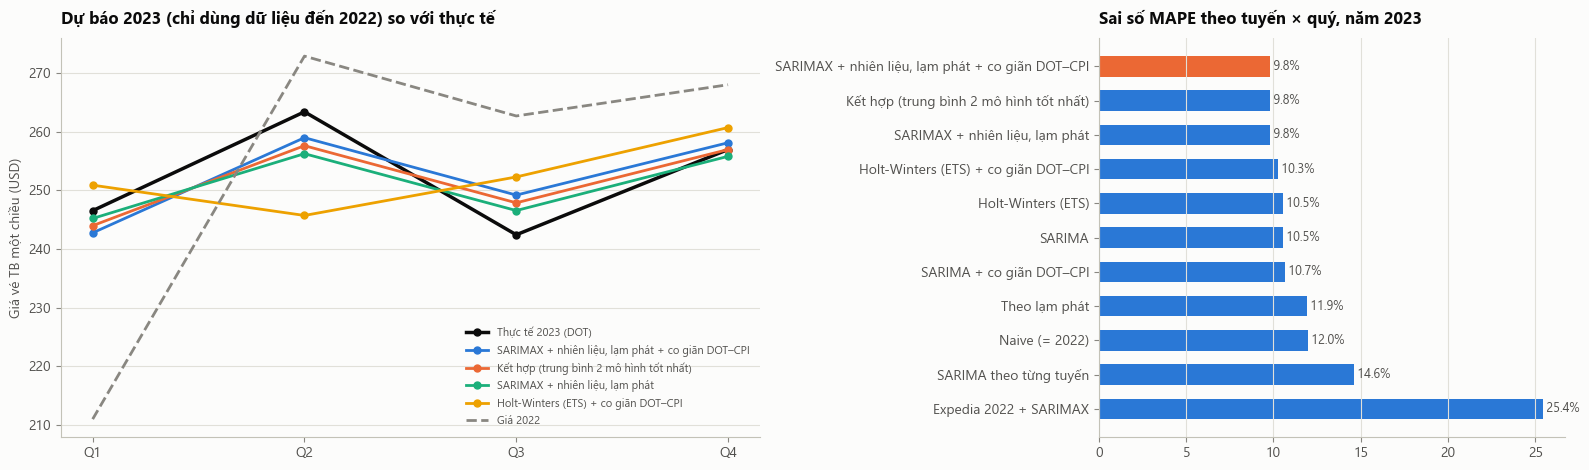

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.8), gridspec_kw={"width_ratios": [3, 2]})
nat = bt.groupby("quarter")[["actual"] + MODELS].mean()
x = np.arange(4)
axes[0].plot(x, nat.actual, color=INK, marker="o", linewidth=2.5, label="Thực tế 2023 (DOT)")
for i, c in enumerate(bt_score.index[:4]):
    axes[0].plot(x, nat[c], color=SERIES[i], marker="o", label=c)
axes[0].plot(x, bt.groupby("quarter").fare_2022.mean(), color=MUTED, linestyle="--", label="Giá 2022")
axes[0].set_xticks(x, ["Q1", "Q2", "Q3", "Q4"]); axes[0].set_ylabel("Giá vé TB một chiều (USD)")
axes[0].set_title("Dự báo 2023 (chỉ dùng dữ liệu đến 2022) so với thực tế"); axes[0].legend(fontsize=8)
o = bt_score.sort_values("MAPE_%", ascending=False)
axes[1].barh(o.index, o["MAPE_%"], color=[SERIES[1] if i == len(o) - 1 else SERIES[0] for i in range(len(o))], height=0.6)
for yy, v in enumerate(o["MAPE_%"]):
    axes[1].text(v, yy, f" {v:.1f}%", va="center", fontsize=9, color=INK_2)
axes[1].set_title("Sai số MAPE theo tuyến × quý, năm 2023"); axes[1].grid(axis="x"); axes[1].grid(axis="y", visible=False)
plt.tight_layout(); plt.savefig(f"{EXPORTS}/fig_06_backtest_2023.png", dpi=150); plt.show()

## 3. Hiệu chỉnh cho sát năm 2023, rồi kiểm tra lại trên Q1/2024

- Lấy mô hình có MAPE thấp nhất trên 2023.
- **Hệ số hiệu chỉnh độ lệch** = tổng giá thực tế 2023 / tổng giá dự báo 2023 (sửa lỗi dự báo cao hoặc thấp có hệ thống).
- **Hiệu chỉnh theo tuyến**: với mỗi tuyến, tỉ số thực tế / dự báo của 2023 được co về 1 (trọng số 50%) để tránh khớp quá mức.
- Sau đó **học lại với dữ liệu đến hết 2023** và dự báo **Q1/2024** — quý mà mô hình chưa thấy — để kiểm tra.

In [9]:
BEST = bt_score.index[0]
bias = bt.actual.sum() / bt[BEST].sum()
route_adj = (bt.actual / bt[BEST]).groupby("pair").mean()
route_adj = 1 + 0.5 * (route_adj / bias - 1)            # co về 1 (shrinkage 50%)
bt["Đã hiệu chỉnh"] = bt[BEST] * bias * bt.index.get_level_values("pair").map(route_adj).values
calib = score(bt, [BEST, "Đã hiệu chỉnh"])
print(f"Mô hình tốt nhất: {BEST} | hệ số hiệu chỉnh độ lệch = {bias:.4f}")
calib

Mô hình tốt nhất: SARIMAX + nhiên liệu, lạm phát + co giãn DOT–CPI | hệ số hiệu chỉnh độ lệch = 1.0003


,MAPE_%,MAE_USD,Bias_%,n
"SARIMAX + nhiên liệu, lạm phát + co giãn DOT–CPI",9.81,23.50,-0.03,408.0
Đã hiệu chỉnh,7.38,17.97,0.19,408.0


In [10]:
# Kiểm tra trên Q1/2024: học với dữ liệu đến 12/2023, dự báo 1 quý
best_key = {v: k for k, v in CPI_METHODS.items()}.get(BEST.replace(ELASTIC, ""), "sarimax")
g24 = quarter_growth(fc_monthly("2023-12-01", 3, best_key)[0], 2024, 2023)[1] if best_key != "naive" else 1.0
if BEST.endswith(ELASTIC):
    a23, b23, _ = fit_elasticity(2023)           # học lại hệ số co giãn với dữ liệu đến hết 2023
    g24 = to_route_growth(g24, a23, b23)
d23 = dot[dot.year == 2023].set_index(["pair", "quarter"])["fare"]
act24 = dot[(dot.year == 2024) & (dot.quarter == 1)].set_index("pair")["fare"]
v = pd.DataFrame({"actual": act24})
v["Naive (= Q1/2023)"] = [d23.get((p, 1), np.nan) for p in v.index]
v[f"{BEST} (chưa hiệu chỉnh)"] = v["Naive (= Q1/2023)"] * g24
if BEST == "SARIMA theo từng tuyến":
    v[f"{BEST} (chưa hiệu chỉnh)"] = [route_forecast(p, 2023, 1)[0] for p in v.index]
v["Đã hiệu chỉnh theo 2023"] = v[f"{BEST} (chưa hiệu chỉnh)"] * [route_adj.get(p, 1.0) for p in v.index]
val24 = score(v, [c for c in v.columns if c != "actual"])
val24.to_csv(f"{EXPORTS}/06_validation_2024Q1.csv")
print("Kiểm tra trên Q1/2024 (thực tế DOT):")
val24

Kiểm tra trên Q1/2024 (thực tế DOT):


,MAPE_%,MAE_USD,Bias_%,n
Naive (= Q1/2023),10.29,25.83,-4.22,102.0
"SARIMAX + nhiên liệu, lạm phát + co giãn DOT–CPI (chưa hiệu chỉnh)",14.89,38.38,-13.10,102.0
Đã hiệu chỉnh theo 2023,14.22,37.76,-12.71,102.0


## 4. Dự báo đến hết 2027

**4a. Chỉ số giá vé toàn quốc theo tháng.** CPI vé máy bay có số liệu thực tế đến **08/2026**; mô hình tốt nhất
(học lại trên toàn bộ chuỗi) dự báo **09/2026 → 12/2027** kèm khoảng tin cậy 80%.

In [11]:
last = m["cpi_airfare"].dropna().index.max()
steps = (2027 - last.year) * 12 + (12 - last.month)
fc_key = best_key if best_key in ("sarima", "sarimax") else "sarimax"
fc, lo, hi = fc_monthly(last, steps, fc_key)
cpi_fc = pd.DataFrame({"cpi_airfare": fc, "lo80": lo, "hi80": hi})
hist = m.loc["2015":, ["cpi_airfare"]].assign(lo80=np.nan, hi80=np.nan)
cpi_path = pd.concat([hist.assign(loai="thực tế"), cpi_fc.assign(loai="dự báo")])
cpi_path.round(2).to_csv(f"{EXPORTS}/06_forecast_cpi_airfare_monthly.csv", index_label="date")

yearly = cpi_path.groupby(cpi_path.index.year)["cpi_airfare"].mean()
growth = (yearly / yearly.shift(1) - 1) * 100
print(f"Mô hình dự báo: {CPI_METHODS[fc_key]}; thực tế đến {last:%m/%Y}")
pd.DataFrame({"CPI vé máy bay TB năm": yearly.round(1), "% so với năm trước": growth.round(1)}).loc[2019:]

Mô hình dự báo: SARIMAX + nhiên liệu, lạm phát; thực tế đến 08/2026


,CPI vé máy bay TB năm,% so với năm trước
2019,265.4,0.2
2020,217.5,-18.0
2021,217.5,0.0
2022,283.1,30.2
2023,267.2,-5.6
2024,261.6,-2.1
2025,256.1,-2.1
2026,310.7,21.3
2027,342.9,10.4


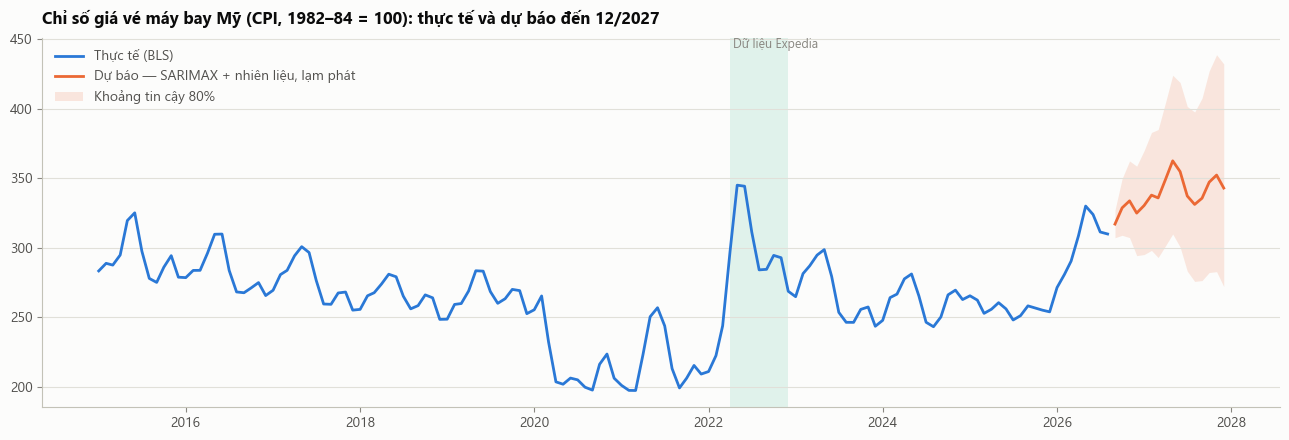

In [12]:
fig, ax = plt.subplots(figsize=(13, 4.5))
h = cpi_path[cpi_path.loai == "thực tế"]; f = cpi_path[cpi_path.loai == "dự báo"]
ax.plot(h.index, h.cpi_airfare, color=SERIES[0], label="Thực tế (BLS)")
ax.plot(f.index, f.cpi_airfare, color=SERIES[1], label=f"Dự báo — {CPI_METHODS[fc_key]}")
ax.fill_between(f.index, f.lo80, f.hi80, color=SERIES[1], alpha=0.15, linewidth=0, label="Khoảng tin cậy 80%")
ax.axvspan(pd.Timestamp("2022-04-01"), pd.Timestamp("2022-11-30"), color=SERIES[2], alpha=0.12, linewidth=0)
ax.text(pd.Timestamp("2022-04-15"), ax.get_ylim()[1], "Dữ liệu Expedia", color=MUTED, fontsize=9, va="top")
ax.set_title("Chỉ số giá vé máy bay Mỹ (CPI, 1982–84 = 100): thực tế và dự báo đến 12/2027"); ax.legend(loc="upper left")
plt.tight_layout(); plt.savefig(f"{EXPORTS}/fig_06_cpi_forecast.png", dpi=150); plt.show()

**4b. Giá từng tuyến theo tháng, 2023 → 2027.**

Giá tuyến r, tháng t = *giá Expedia của tuyến r trong **cùng tháng** năm 2022* × *hệ số tăng/giảm so với cùng tháng 2022*
× *hệ số hiệu chỉnh tuyến (từ backtest 2023)*, trong đó hệ số tăng/giảm = exp(α·số năm + β·Δlog CPI vé máy bay) với
α, β là **độ co giãn DOT–CPI** học trên 2005 → Q1/2024. So sánh cùng tháng nên không bị lệch mùa vụ.
Các tháng 12–3 (Expedia 2022 không có) lấy mức giá TB của tuyến × mùa vụ theo quý của tuyến đó trong dữ liệu DOT 2022.
Có hai thang giá: **giá tìm kiếm trên Expedia** (giống dữ liệu gốc) và **giá vé thực bán** (thang DOT, × K).

In [13]:
ALPHA, BETA, R_EL = fit_elasticity(2024, 1)
print(f"Co giãn DOT–CPI (2005 → Q1/2024): β = {BETA:.3f}, α = {ALPHA * 100:+.2f}%/năm, r = {R_EL:.3f}")
cpi_all_path = pd.concat([m.loc[:last, "cpi_airfare"], fc])

exp_rm["mo"] = exp_rm.date.dt.month
lvl = exp_rm.set_index(["route", "mo"])["avg_fare"]
route_pair = exp_rm.drop_duplicates("route").set_index("route")["pair"]
route_mean = exp_rm.groupby("route").apply(lambda g: np.average(g.avg_fare, weights=g.n), include_groups=False)
dq = d22.unstack()                                              # cặp sân bay × quý (DOT 2022)
q_factor = dq.div(dq[[2, 3, 4]].mean(axis=1), axis=0)          # mùa vụ theo quý so với Q2–Q4

def level_2022(route, mo):
    if (route, mo) in lvl.index and mo not in (4, 11):          # tháng 4 và 11 chỉ có một phần tháng
        return lvl[(route, mo)]
    q = (mo - 1) // 3 + 1
    f = q_factor.loc[route_pair[route], q] if route_pair[route] in q_factor.index else 1.0
    return route_mean[route] * (f if np.isfinite(f) else 1.0)

# --- Hiệu chỉnh phép quy đổi CPI → giá tuyến cho khớp thực tế 2023 (dùng CPI thực tế 2023) ---
cq = m.groupby([m.index.year, m.index.quarter])["cpi_airfare"].mean()
a23, b23, _ = fit_elasticity(2023)
map23 = pd.Series([d22[(p, q)] * to_route_growth(cq[(2023, q)] / cq[(2022, q)], a23, b23) for p, q in bt.index], index=bt.index)
BIAS_MAP = bt.actual.sum() / map23.sum()
ADJ_MAP = ((bt.actual / map23).groupby("pair").mean() / BIAS_MAP)
ADJ_MAP = 1 + 0.5 * (ADJ_MAP - 1)                               # co về 1 (shrinkage 50%)
cal23 = pd.DataFrame({"actual": bt.actual, "Quy đổi CPI (chưa hiệu chỉnh)": map23,
                      "Quy đổi CPI (đã hiệu chỉnh theo 2023)": map23 * BIAS_MAP * map23.index.get_level_values("pair").map(ADJ_MAP).values})
print(f"Hệ số hiệu chỉnh mức giá theo 2023: {BIAS_MAP:.4f}")
display(score(cal23, cal23.columns[1:]))

# Kiểm tra trên Q1/2024 — quý KHÔNG dùng để hiệu chỉnh: giá Q1/2022 × tăng trưởng 2 năm theo CPI thực tế × hiệu chỉnh
v2 = pd.DataFrame({"actual": act24})
v2["Naive (= Q1/2023)"] = [d23.get((p, 1), np.nan) for p in v2.index]
g2 = cq[(2024, 1)] / cq[(2022, 1)]
v2["Quy đổi CPI đã hiệu chỉnh theo 2023"] = [d22.get((p, 1), np.nan) * to_route_growth(g2, a23, b23, years=2) * BIAS_MAP * ADJ_MAP.get(p, 1.0)
                                            for p in v2.index]
val24_map = score(v2, v2.columns[1:])
pd.concat([val24, val24_map.drop(index="Naive (= Q1/2023)")]).to_csv(f"{EXPORTS}/06_validation_2024Q1.csv")
print("Kiểm tra trên Q1/2024 (thực tế DOT):")
display(val24_map)

months = pd.date_range("2022-04-01", "2027-12-01", freq="MS")
rows = []
for route in route_mean.index:
    pair = route_pair[route]
    adj = ADJ_MAP.get(pair, 1.0) * BIAS_MAP
    for t in months:
        base = level_2022(route, t.month)
        if t.year == 2022:
            fare = base                                          # 2022: giá thực tế Expedia
        else:
            g = cpi_all_path[t] / m.loc[f"2022-{t.month:02d}-01", "cpi_airfare"]
            fare = base * to_route_growth(g, ALPHA, BETA, years=t.year - 2022) * adj
        rows.append((route, pair, t, fare, t > last))
route_month = pd.DataFrame(rows, columns=["route", "pair", "month", "expedia_fare", "is_forecast"])
route_month["actual_ticket_fare"] = route_month.expedia_fare * K_SCALE
route_month["year"] = route_month.month.dt.year
route_month.round(2).to_csv(f"{EXPORTS}/06_forecast_route_month.csv", index=False)

# So sánh các năm trên CÙNG các tháng 4–11 (khoảng thời gian có dữ liệu Expedia 2022) để không lẫn mùa vụ
same_months = route_month[route_month.month.dt.month.between(4, 11)]
summary_year = (same_months.groupby("year")[["expedia_fare", "actual_ticket_fare"]].mean().round(1)
                .rename(columns={"expedia_fare": "Giá Expedia TB (USD)", "actual_ticket_fare": "Giá vé thực bán TB (USD)"}))
summary_year["% so với 2022"] = ((summary_year.iloc[:, 0] / summary_year.iloc[0, 0] - 1) * 100).round(1)
summary_year.to_csv(f"{EXPORTS}/06_forecast_summary_by_year.csv")
summary_year

Co giãn DOT–CPI (2005 → Q1/2024): β = 0.856, α = +0.84%/năm, r = 0.836
Hệ số hiệu chỉnh mức giá theo 2023: 1.0369


,MAPE_%,MAE_USD,Bias_%,n
Quy đổi CPI (chưa hiệu chỉnh),10.77,24.92,-3.56,408.0
Quy đổi CPI (đã hiệu chỉnh theo 2023),8.05,18.67,0.22,408.0


Kiểm tra trên Q1/2024 (thực tế DOT):


,MAPE_%,MAE_USD,Bias_%,n
Naive (= Q1/2023),10.29,25.83,-4.22,102.0
Quy đổi CPI đã hiệu chỉnh theo 2023,10.07,25.11,-2.60,102.0


,Giá Expedia TB (USD),Giá vé thực bán TB (USD),% so với 2022
year,,,
2022,346.3,271.7,0.0
2023,321.1,251.9,-7.3
2024,319.3,250.6,-7.8
2025,314.4,246.7,-9.2
2026,385.3,302.3,11.3
2027,415.4,326.0,20.0


**4c. Dự đoán theo ngày cho đến ngày bay.** Hệ số đường giá theo số ngày đặt trước học từ 82 triệu vé 2022
(trung vị theo tuyến, làm trơn 5 ngày). Giá dự báo của tuyến r, tháng t, đặt trước d ngày = giá tháng t × hệ số(r, d).

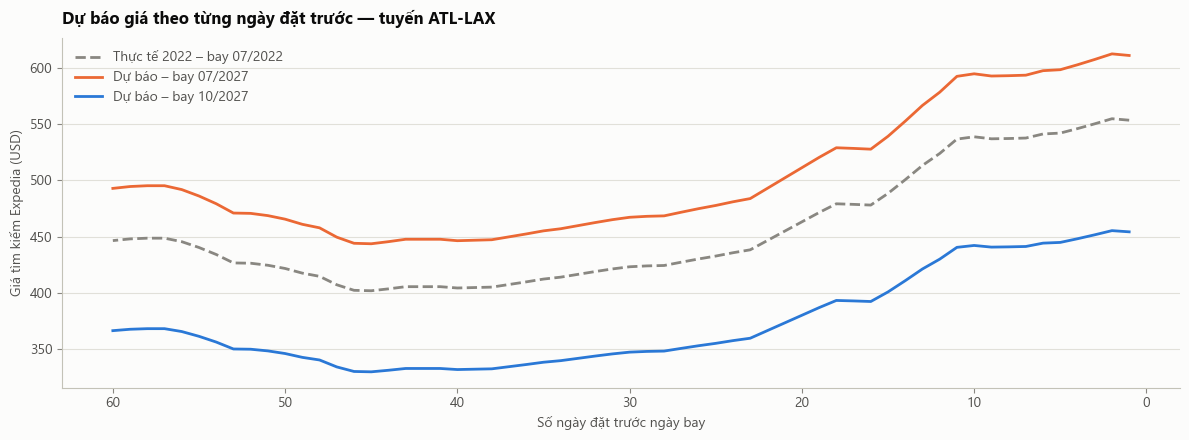

In [14]:
curve = exp_curve[exp_curve.days_before.between(1, 60)].copy()
curve["mult"] = curve.median_fare / curve.groupby("route").median_fare.transform("median")
curve = curve.sort_values(["route", "days_before"])
curve["mult"] = curve.groupby("route").mult.transform(lambda s: s.rolling(5, center=True, min_periods=1).mean())
nat_curve = exp_curve_all[exp_curve_all.days_before.between(1, 60)].sort_values("days_before")
nat_curve["mult"] = (nat_curve.median_fare / nat_curve.median_fare.median()).rolling(5, center=True, min_periods=1).mean()
curve[["route", "days_before", "mult", "n"]].round(4).to_csv(f"{EXPORTS}/06_booking_curve_multipliers.csv", index=False)
nat_curve[["days_before", "mult", "n"]].round(4).to_csv(f"{EXPORTS}/06_booking_curve_national.csv", index=False)

# Ví dụ: tuyến có nhiều vé nhất, bay tháng 7/2027 (mùa hè) và tháng 10/2027
ex_route = exp_rm.groupby("route").n.sum().idxmax()
fig, ax = plt.subplots(figsize=(12, 4.5))
cr = curve[curve.route == ex_route]
for i, mon in enumerate(["2022-07-01", "2027-07-01", "2027-10-01"]):
    lvl = route_month[(route_month.route == ex_route) & (route_month.month == mon)].expedia_fare.iloc[0]
    ax.plot(cr.days_before, lvl * cr.mult, color=[MUTED, SERIES[1], SERIES[0]][i],
            linestyle="--" if i == 0 else "-", label=("Thực tế 2022 – bay " if i == 0 else "Dự báo – bay ") + pd.Timestamp(mon).strftime("%m/%Y"))
ax.invert_xaxis(); ax.set_xlabel("Số ngày đặt trước ngày bay"); ax.set_ylabel("Giá tìm kiếm Expedia (USD)")
ax.set_title(f"Dự báo giá theo từng ngày đặt trước — tuyến {ex_route}"); ax.legend()
plt.tight_layout(); plt.savefig(f"{EXPORTS}/fig_06_booking_curve_2027.png", dpi=150); plt.show()

In [15]:
meta = {"best_backtest_model": BEST, "bias_factor_2023": round(float(BIAS_MAP), 4), "bias_factor_backtest_model": round(float(bias), 4), "K_expedia_to_dot": round(float(K_SCALE), 4),
        "cpi_forecast_model": CPI_METHODS[fc_key], "elasticity_beta": round(float(BETA), 3),
        "elasticity_alpha_pct_per_year": round(float(ALPHA) * 100, 2), "elasticity_r": round(float(R_EL), 3), "cpi_actual_until": f"{last:%Y-%m}", "fuel_lag_months": FUEL_LAG,
        "backtest_2023": bt_score.round(2).to_dict(orient="index"), "validation_2024Q1": val24.round(2).to_dict(orient="index")}
json.dump(meta, open(f"{EXPORTS}/06_forecast_meta.json", "w", encoding="utf-8"), ensure_ascii=False, indent=2)
meta

{'best_backtest_model': 'SARIMAX + nhiên liệu, lạm phát + co giãn DOT–CPI',
 'bias_factor_2023': 1.0369,
 'bias_factor_backtest_model': 1.0003,
 'K_expedia_to_dot': 0.7847,
 'cpi_forecast_model': 'SARIMAX + nhiên liệu, lạm phát',
 'elasticity_beta': 0.856,
 'elasticity_alpha_pct_per_year': 0.84,
 'elasticity_r': 0.836,
 'cpi_actual_until': '2026-08',
 'fuel_lag_months': 2,
 'backtest_2023': {'SARIMAX + nhiên liệu, lạm phát + co giãn DOT–CPI': {'MAPE_%': 9.81,
   'MAE_USD': 23.5,
   'Bias_%': -0.03,
   'n': 408.0},
  'Kết hợp (trung bình 2 mô hình tốt nhất)': {'MAPE_%': 9.81,
   'MAE_USD': 23.39,
   'Bias_%': -0.29,
   'n': 408.0},
  'SARIMAX + nhiên liệu, lạm phát': {'MAPE_%': 9.82,
   'MAE_USD': 23.33,
   'Bias_%': -0.54,
   'n': 408.0},
  'Holt-Winters (ETS) + co giãn DOT–CPI': {'MAPE_%': 10.28,
   'MAE_USD': 24.57,
   'Bias_%': 0.03,
   'n': 408.0},
  'Holt-Winters (ETS)': {'MAPE_%': 10.52,
   'MAE_USD': 25.03,
   'Bias_%': -0.46,
   'n': 408.0},
  'SARIMA': {'MAPE_%': 10.54, 'MAE_U